# Studentische Wohnlageanalyse Leipzig — Feature-Extraktion je Adresse

In [8]:
%pip install osm2geojson

In [9]:
from google.colab import drive
drive.mount('/content/drive')

EXCEL_PATH = "/content/drive/MyDrive/Computational Spatial Humanities/Wohnlage_zum_Leipziger_Mietspiegel_2025-2027.xlsx"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
import json, time, re, unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from scipy.spatial import cKDTree
import requests

CACHE = Path("cache"); CACHE.mkdir(exist_ok=True)
OUT   = Path("output"); OUT.mkdir(exist_ok=True)

CRS_METRIC = "EPSG:25833"
CRS_WGS    = "EPSG:4326"

OVERPASS_URL = "https://overpass-api.de/api/interpreter"

AREA_FILTER = 'area["de:amtlicher_gemeindeschluessel"="14713000"]->.leipzig;'

## Adressen laden & normalisieren

In [12]:
def norm_street(s: str) -> str:
    s = str(s).strip().lower()
    s = unicodedata.normalize("NFC", s)
    s = re.sub(r"str\.\s*$", "straße", s)          # "Kantstr." -> "kantstraße"
    s = re.sub(r"\bstr\.", "straße", s)            # "Str. des 18. Oktober"
    s = re.sub(r"\s+", " ", s)
    return s

def norm_hnr(h: str) -> str:
    h = str(h).strip().lower().replace(" ", "")
    return h                                        # "8A" -> "8a"

adr = pd.read_excel(EXCEL_PATH)
adr.columns = ["strasse", "hausnummer", "wohnlage_offiziell", "faktor"]
adr["key"] = adr["strasse"].map(norm_street) + "|" + adr["hausnummer"].map(norm_hnr)

print(len(adr), "Adressen,", adr["key"].nunique(), "eindeutige Keys")
adr.head()

73261 Adressen, 73261 eindeutige Keys


,strasse,hausnummer,wohnlage_offiziell,faktor,key
0,Tröndlinring,2,Kerngebietslage,1.147,tröndlinring|2
1,Tröndlinring,3,Kerngebietslage,1.147,tröndlinring|3
2,Tröndlinring,7,Kerngebietslage,1.147,tröndlinring|7
3,Tröndlinring,8,Kerngebietslage,1.147,tröndlinring|8
4,Tröndlinring,9,Kerngebietslage,1.147,tröndlinring|9


## Georeferenzierung über OSM-Adressdump


In [14]:
OVERPASS_URLS = [
    "https://overpass.kumi.systems/api/interpreter",
    "https://overpass.private.coffee/api/interpreter",
    "https://overpass-api.de/api/interpreter",
]

HEADERS = {
    "User-Agent": "Studentische Wohnlagenanalyse/Uni Leipzig Computational Spatial Humanities - SoSe2026; zk09noke@studserv.uni-leipzig.de)",
    "Accept": "application/json",
}

_working_url = {"url": None}   # merkt sich den zuletzt erfolgreichen Endpoint

def overpass(query: str, cache_name: str, sleep=5) -> dict:
    f = CACHE / f"{cache_name}.json"
    if f.exists():
        return json.loads(f.read_text())

    urls = OVERPASS_URLS.copy()
    if _working_url["url"] in urls:
        urls.remove(_working_url["url"])
        urls.insert(0, _working_url["url"])

    last_err = None
    for url in urls:
        try:
            r = requests.post(url, data={"data": query},
                              headers=HEADERS, timeout=900)
            r.raise_for_status()
            data = r.json()
            remark = data.get("remark", "")
            if "error" in remark.lower() or "timed out" in remark.lower():
                raise requests.RequestException(f"Overpass-Abbruch: {remark}")
            if not data.get("elements"):
                raise requests.RequestException("leere Antwort (0 elements)")
            f.write_text(json.dumps(data))
            _working_url["url"] = url
            time.sleep(sleep)
            return data
        except (requests.RequestException, ValueError) as e:
            print(f"{url} fehlgeschlagen ({e}), versuche nächsten …")
            last_err = e
    raise last_err

Q_ADDR = f"""[out:json][timeout:900];
{AREA_FILTER}
nwr["addr:housenumber"](area.leipzig);
out center tags;"""

raw = overpass(Q_ADDR, "osm_adressen_leipzig")
rows = []
for el in raw["elements"]:
    tags = el.get("tags", {})
    street, hnr = tags.get("addr:street"), tags.get("addr:housenumber")
    if not (street and hnr):
        continue
    lat = el.get("lat") or el.get("center", {}).get("lat")
    lon = el.get("lon") or el.get("center", {}).get("lon")
    if lat is None:
        continue
    for h in re.split(r"[;,]", hnr):
        rows.append((norm_street(street) + "|" + norm_hnr(h), lat, lon))

osm_adr = (pd.DataFrame(rows, columns=["key", "lat", "lon"])
             .groupby("key", as_index=False).mean())   # Duplikate mitteln
print(len(osm_adr), "eindeutige OSM-Adressen")

74014 eindeutige OSM-Adressen


In [15]:
adr = adr.merge(osm_adr, on="key", how="left")
match = adr["lat"].notna().mean()
print(f"Direkte Match-Quote: {match:.1%}")

# Fallback: Straßen-Zentroid für ungematchte Adressen
strassen_zentroid = (adr.dropna(subset=["lat"])
                        .assign(s=lambda d: d["key"].str.split("|").str[0])
                        .groupby("s")[["lat", "lon"]].mean())
mask = adr["lat"].isna()
s_of = adr.loc[mask, "key"].str.split("|").str[0]
adr.loc[mask, ["lat", "lon"]] = strassen_zentroid.reindex(s_of).values
adr["geo_qualitaet"] = np.where(mask, "strassen_zentroid", "hausnummer")
print(f"Nach Fallback noch ohne Koordinate: {adr['lat'].isna().sum()}")

gdf = gpd.GeoDataFrame(adr, geometry=gpd.points_from_xy(adr.lon, adr.lat),
                       crs=CRS_WGS).to_crs(CRS_METRIC)

Direkte Match-Quote: 98.6%
Nach Fallback noch ohne Koordinate: 20


# Ortsteil je Adresse

In [16]:
ORTSTEIL_GEOJSON = "/content/drive/MyDrive/Computational Spatial Humanities/Ortsteile_Leipzig_UTM33N.json"

ortsteile = gpd.read_file(ORTSTEIL_GEOJSON).to_crs(CRS_METRIC)

gdf = gpd.sjoin(gdf, ortsteile[["geometry", "Name"]].rename(columns={"Name": "ortsteil"}),
                how="left", predicate="within").drop(columns="index_right")
print("ohne Ortsteil:", gdf["ortsteil"].isna().sum())

valid = gdf.geometry.x.notna() & gdf.geometry.y.notna()
print(f"{(~valid).sum()} von {len(gdf)} Adressen ohne Koordinate")

ohne Ortsteil: 20
20 von 73261 Adressen ohne Koordinate


## POIs aus OSM

In [24]:
POI_QUERIES = {
    "oepnv": '''(node["highway"="bus_stop"](area.leipzig);
                 nwr["railway"="tram_stop"](area.leipzig);
                 nwr["railway"="station"](area.leipzig););''',
    "discounter": '''nwr["shop"="supermarket"]["brand"~"Aldi|Lidl|Penny|Netto|Norma",i](area.leipzig);''',
    "fitnessstudio": '''nwr["leisure"="fitness_centre"](area.leipzig);''',
    "cafe": '''nwr["amenity"="cafe"](area.leipzig);''',
    "bar_club": '''(nwr["amenity"="bar"](area.leipzig);
                    nwr["amenity"="pub"](area.leipzig);
                    nwr["amenity"="nightclub"](area.leipzig););''',
    "spaeti": '''(nwr["shop"="kiosk"](area.leipzig);
                  nwr["shop"="convenience"](area.leipzig););''',
    "sportplaetze": '''nwr["leisure"="pitch"](area.leipzig);''',
    "doener": '''(nwr["amenity"="fast_food"]["cuisine"~"kebab|doner|döner|turkish",i](area.leipzig);
               nwr["amenity"="fast_food"]["name"~"döner|doener|kebap|kebab",i](area.leipzig););'''

}

def poi_gdf(name: str, body: str) -> gpd.GeoDataFrame:
    q = f"[out:json][timeout:300];\n{AREA_FILTER}\n{body}\nout center tags;"
    data = overpass(q, f"poi_{name}")
    pts = []
    for el in data["elements"]:
        lat = el.get("lat") or el.get("center", {}).get("lat")
        lon = el.get("lon") or el.get("center", {}).get("lon")
        if lat is not None:
            pts.append({"name": el.get("tags", {}).get("name"), "lat": lat, "lon": lon})
    g = gpd.GeoDataFrame(pts, geometry=gpd.points_from_xy(
            [p["lon"] for p in pts], [p["lat"] for p in pts]), crs=CRS_WGS)
    return g.to_crs(CRS_METRIC)

pois = {name: poi_gdf(name, body) for name, body in POI_QUERIES.items()}
{k: len(v) for k, v in pois.items()}

{'oepnv': 1871,
 'discounter': 105,
 'fitnessstudio': 61,
 'cafe': 291,
 'bar_club': 288,
 'spaeti': 195,
 'sportplaetze': 1179,
 'doener': 162}

In [25]:
GYM_WHITELIST = [
    "Fitness First",
    "McFit",
    "Clever fit",
    "JOHN REED Fitness",
    "Matthias Sport Center",
    "all inclusive Fitness Leipzig-Südvorstadt",
    "Strong Iron Powergym",
    "Happy Fit",
    "FitX",
]

vorher = len(pois["fitnessstudio"])
pois["fitnessstudio"] = pois["fitnessstudio"][
    pois["fitnessstudio"]["name"].isin(GYM_WHITELIST)].copy()
print(f"fitnessstudio: {vorher} -> {len(pois['fitnessstudio'])} nach Whitelist")

fitnessstudio: 61 -> 13 nach Whitelist


# Manuell

In [26]:
FREIBAD_ADRESSEN = [
    ("Sommerbad Kleinzschocher", "Küchenholzallee", "75"),
    ("Ökobad Lindenthal",        "Am Freibad",      "3"),
    #("Kinderfreibecken Robbe",   "Kleiststraße",    "54"),
    ("Sommerbad Schönefeld",     "Volbedingstraße", "39"),
    ("Schreberbad",              "Schreberstraße",  "15"),
    ("Sommerbad Südost",         "Oststraße",       "173"),
]

MENSA_ADRESSEN = [
    ("Mensa am Park",              "Universitätsstraße",       "5"),
    ("Mensa Schönauer Straße",     "Schönauer Straße",         "113a"),
    ("Mensa Academica",            "Karl-Liebknecht-Straße",   "145"),
    ("Mensa am Elsterbecken",      "Marschnerstraße",          "29c"),
    ("Mensa am Medizincampus",     "Liebigstraße",             "23"),   # offiziell 23/25
    ("Mensa An den Tierkliniken",  "An den Tierkliniken",      "5"),
    ("Mensa Peterssteinweg",       "Straße des 17. Juni",      "2a"),
    ("Mensaria am Botan. Garten",  "Philipp-Rosenthal-Straße", "33"),
]

BIBLIOTHEK_ADRESSEN = [
    ("Bibliotheca Albertina",            "Beethovenstraße",     "6"),
    ("Campus-Bibliothek",                "Universitätsstraße",  "3"),
    ("Bibliothek Erziehung/Sportwiss.",  "Marschnerstraße",     "29e"),  # Haus 5
    ("Bibliothek Kunst",                 "Dittrichring",        "18"),   # offiziell 18–20
    ("Bibliothek Medizin/Naturwiss.",    "Liebigstraße",        "23"),   # offiziell 23/25
    ("Bibliothek Recht I",               "Burgstraße",          "27"),
    ("Bibliothek Recht II",              "Burgstraße",          "21"),
    ("Bibliothek Regionalwiss.",         "Schillerstraße",      "6"),
    ("Bibliothek Veterinärmedizin",      "An den Tierkliniken", "5"),
]

CAMPUS_ADRESSEN = [
    ("Campus Augustusplatz (Zentrum)",     "Augustusplatz",        "10"),  # Mathe/Inf, Theologie; Jura (Burgstr.), WiFa (Grimmaische Str.) direkt daneben
    ("GWZ Beethovenstraße (Musikviertel)", "Beethovenstraße",      "15"),  # Philologie, SozPhil, GKR
    ("Campus Jahnallee",                   "Jahnallee",            "59"),  # Sportwiss.; Erziehungswiss. (Marschnerstr. 31) nebenan
    ("Medizincampus Liebigstraße",         "Liebigstraße",         "27"),  # Medizinische Fakultät / UKL
    ("Naturwiss. Campus Linnéstraße",      "Linnéstraße",          "5"),   # Physik; Chemie (Johannisallee 29), Lebenswiss. (Talstr. 33) nebenan
    ("Campus An den Tierkliniken",         "An den Tierkliniken",  "19"),  # Veterinärmedizin
]

def adressen_zu_pois(adressen, kategorie = None):
    """Handgepflegte (Name, Straße, Hausnummer)-Liste -> POI-GeoDataFrame.
    Koordinaten kommen per Lookup aus dem OSM-Adressdump (osm_adr).
    Nicht auffindbare Adressen werden geflagt und übersprungen."""
    lookup = osm_adr.set_index("key")
    rows = []
    for name, s, h in adressen:
        key = norm_street(s) + "|" + norm_hnr(h)
        if key in lookup.index:
            r = lookup.loc[key]
            rows.append({"name": name, "lon": r["lon"], "lat": r["lat"]})
        else:
            print(f"WARNUNG [{kategorie}]: '{name}' ({s} {h}) nicht im OSM-Dump — übersprungen")
    g = gpd.GeoDataFrame(
        {"name": [r["name"] for r in rows]},
        geometry=gpd.points_from_xy([r["lon"] for r in rows],
                                    [r["lat"] for r in rows]),
        crs=CRS_WGS).to_crs(CRS_METRIC)
    print(f"{kategorie}: {len(g)} von {len(adressen)} Adressen georeferenziert")
    return g

pois["freibad"]     = adressen_zu_pois(FREIBAD_ADRESSEN, "freibad")
pois["mensa"]       = adressen_zu_pois(MENSA_ADRESSEN,   "mensa")
pois["bibliothek"]  = adressen_zu_pois(BIBLIOTHEK_ADRESSEN,   "bibliothek")
pois["uni"]         = adressen_zu_pois(CAMPUS_ADRESSEN, "uni")

freibad: 5 von 5 Adressen georeferenziert
mensa: 8 von 8 Adressen georeferenziert
bibliothek: 9 von 9 Adressen georeferenziert
uni: 6 von 6 Adressen georeferenziert


In [27]:
def drucke_manuell_format(kategorie):
    g = pois[kategorie].to_crs(CRS_WGS)
    print(f'    "{kategorie}": [')
    for _, p in g.iterrows():
        print(f'        ("{p["name"]}", {p.geometry.x:.4f}, {p.geometry.y:.4f}),')
    print('    ],')

drucke_manuell_format("uni")

    "uni": [
        ("Campus Augustusplatz (Zentrum)", 12.3793, 51.3388),
        ("GWZ Beethovenstraße (Musikviertel)", 12.3685, 51.3318),
        ("Campus Jahnallee", 12.3502, 51.3395),
        ("Medizincampus Liebigstraße", 12.3913, 51.3315),
        ("Naturwiss. Campus Linnéstraße", 12.3917, 51.3270),
        ("Campus An den Tierkliniken", 12.3924, 51.3193),
    ],


In [28]:
MANUELL = {
    #"Innenstadt" = Distanz zu einem festen Referenzpunkt (Markt).
    "innenstadt": [
         ("Markt", 12.3745, 51.3403),
    ],
    "mensa": [
        ("Mensa am Park", 12.3782, 51.3379),
        ("Mensa Schönauer Straße", 12.3032, 51.3103),
        ("Mensa Academica", 12.3740, 51.3132),
        ("Mensa am Elsterbecken", 12.3521, 51.3393),
        ("Mensa am Medizincampus", 12.3894, 51.3315),
        ("Mensa An den Tierkliniken", 12.3910, 51.3206),
        ("Mensa Peterssteinweg", 12.3733, 51.3331),
        ("Mensaria am Botan. Garten", 12.3903, 51.3272),
    ],
    "bibliothek": [
        ("Bibliotheca Albertina", 12.3682, 51.3325),
        ("Campus-Bibliothek", 12.3785, 51.3383),
        ("Bibliothek Erziehung/Sportwiss.", 12.3533, 51.3399),
        ("Bibliothek Kunst", 12.3717, 51.3412),
        ("Bibliothek Medizin/Naturwiss.", 12.3894, 51.3315),
        ("Bibliothek Recht I", 12.3737, 51.3377),
        ("Bibliothek Recht II", 12.3735, 51.3382),
        ("Bibliothek Regionalwiss.", 12.3775, 51.3372),
        ("Bibliothek Veterinärmedizin", 12.3910, 51.3206),
    ],
    "freibad": [
        ("Sommerbad Kleinzschocher", 12.3391, 51.3164),
        ("Ökobad Lindenthal", 12.3269, 51.3932),
        #("Kinderfreibecken Robbe", 12.3813, 51.3724),
        ("Sommerbad Schönefeld", 12.4114, 51.3629),
        ("Schreberbad", 12.3591, 51.3389),
        ("Sommerbad Südost", 12.4199, 51.3264)
    ],
    "uni": [
        ("Campus Augustusplatz (Zentrum)", 12.3793, 51.3388),
        ("GWZ Beethovenstraße (Musikviertel)", 12.3685, 51.3318),
        ("Campus Jahnallee", 12.3502, 51.3395),
        ("Medizincampus Liebigstraße", 12.3913, 51.3315),
        ("Naturwiss. Campus Linnéstraße", 12.3917, 51.3270),
        ("Campus An den Tierkliniken", 12.3924, 51.3193),
    ],
}

for name, lst in MANUELL.items():
    g = gpd.GeoDataFrame({"name": [x[0] for x in lst]},
        geometry=gpd.points_from_xy([x[1] for x in lst], [x[2] for x in lst]),
        crs=CRS_WGS).to_crs(CRS_METRIC)
    pois[name] = g

# Parks

In [29]:
import osm2geojson

Q_PARK_GEOM = f"""[out:json][timeout:300];
{AREA_FILTER}
nwr["leisure"="park"](area.leipzig);
out geom;"""

data = overpass(Q_PARK_GEOM, "park_polygone")
gj = osm2geojson.json2geojson(data)
parks_alle = gpd.GeoDataFrame.from_features(gj["features"], crs=CRS_WGS).to_crs(CRS_METRIC)
parks_alle = parks_alle[parks_alle.geometry.type.isin(["Polygon", "MultiPolygon"])].copy()
parks_alle["name"] = parks_alle["tags"].apply(lambda t: (t or {}).get("name"))

# Namen ergänzen, die in OSM fehlen
MANUELLE_PARK_NAMEN = {
    663647906: "Promenadenring",
    663647905: "Promenadenring",
    663645121: "Promenadenring",
    663641645: "Promenadenring",
    9221981:   "Promenadenring",
    694353568: "Promenadenring",
    663615308: "Promenadenring",
    663615306: "Promenadenring",
    663610818: "Promenadenring",
    12625382:  "Promenadenring",
    12625383:  "Promenadenring",
    12625389:  "Promenadenring",
    12625384:  "Promenadenring",
    12625385:  "Promenadenring",
    23171591:  "Fritz-von-Harck-Anlage",
    121182858: "Anger-Crottendorfer-Bahnschneise",
    121182943: "Anger-Crottendorfer-Bahnschneise",
}
parks_alle["name"] = parks_alle.apply(
    lambda r: MANUELLE_PARK_NAMEN.get(r["id"], r["name"]), axis=1)

PARK_NAMEN = [
    "Clara-Zetkin-Park", "Promenadenring", "Rosental",
    "agra-Messegelände (Leipzig)", "Volkspark Kleinzschocher", "Friedenspark",
    "Mariannenpark", "Parthenaue", "Lene-Voigt-Park",
    "Arthur-Bretschneider-Park", "Henriettenpark", "Erholungspark Lößnig-Dölitz",
    "Wilhelm-Külz-Park", "Park an der Etzoldschen Sandgrube", "Schönauer Park",
    "Schlosspark Lützschena", "Abtnaundorfer Park", "Grüner Bogen Paunsdorf",
    "Robert-Koch-Platz", "Stadtgarten Brüder-Leplay-Straße", "Fritz-von-Harck-Anlage",
    "Anger-Crottendorfer-Bahnschneise", "Museale Parkanlage Alter Johannisfriedhof",
    "Richard-Wagner-Hain", "Rietzschke-Aue Sellerhausen", "Fockeberg",
]

sel, fehlt = [], []
for name in PARK_NAMEN:
    treffer = parks_alle[parks_alle["name"] == name]
    if treffer.empty:
        treffer = parks_alle[parks_alle["name"].fillna("")
                             .str.contains(name.split()[0], case=False)]
    if treffer.empty:
        fehlt.append(name)
    else:
        sel.append(treffer.assign(park=name))

park_poly = gpd.GeoDataFrame(pd.concat(sel), crs=CRS_METRIC)[["park", "id", "geometry"]]
print(f"{park_poly['park'].nunique()} von {len(PARK_NAMEN)} gematcht; fehlt: {fehlt}")

23 von 26 gematcht; fehlt: ['Parthenaue', 'Museale Parkanlage Alter Johannisfriedhof', 'Fockeberg']


In [30]:
import folium

pp = park_poly.to_crs(CRS_WGS).copy()
pp["flaeche_ha"] = (park_poly.area / 10_000).round(2)

m = folium.Map(location=[51.34, 12.37], zoom_start=11, tiles="cartodbpositron")
folium.GeoJson(
    pp,
    style_function=lambda f: {"fillColor": "#F57C00", "color": "#E65100",
                              "weight": 2, "fillOpacity": 0.55},
    highlight_function=lambda f: {"weight": 4, "fillOpacity": 0.8},
    tooltip=folium.GeoJsonTooltip(fields=["park", "flaeche_ha"],
                                  aliases=["Park", "Fläche (ha)"]),
).add_to(m)
m

/usr/local/lib/python3.13/dist-packages/folium/raster_layers.py:130: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tiles = tiles.build_url(fill_subdomain=False, scale_factor="{r}")  # type: ignore


In [31]:
print(park_poly.assign(ha=(park_poly.area / 10_000).round(1))
               .groupby("park")
               .agg(teile=("geometry", "size"), ha=("ha", "sum"))
               .sort_values("ha", ascending=False).to_string())

                                   teile     ha
park                                           
Erholungspark Lößnig-Dölitz            1  188.3
Volkspark Kleinzschocher               1   72.5
Clara-Zetkin-Park                      1   46.3
agra-Messegelände (Leipzig)            1   39.2
Wilhelm-Külz-Park                      3   22.1
Rosental                               1   20.1
Friedenspark                           1   17.7
Abtnaundorfer Park                     1   17.0
Mariannenpark                          1   15.7
Grüner Bogen Paunsdorf                 1   12.7
Schönauer Park                         1   12.0
Park an der Etzoldschen Sandgrube      1   10.6
Arthur-Bretschneider-Park              1    9.3
Richard-Wagner-Hain                    1    9.0
Promenadenring                        14    7.9
Lene-Voigt-Park                        1    6.3
Stadtgarten Brüder-Leplay-Straße       1    4.4
Schlosspark Lützschena                 2    3.1
Rietzschke-Aue Sellerhausen            1

In [32]:
DETOUR = 1.3

naechster = gpd.sjoin_nearest(
    gdf[["geometry"]].loc[valid], park_poly,
    distance_col="d")[["d"]]
naechster = naechster[~naechster.index.duplicated()]
gdf.loc[valid, "dist_park"] = naechster["d"] * DETOUR

# See

In [34]:
SEE_LISTE = [
    "Cospudener See",     # EU-Badegewässer
    "Kulkwitzer See",     # EU-Badegewässer
    "Markkleeberger See", # EU-Badegewässer
    "Zwenkauer See",      # Badestelle Kap Zwenkau
    "Störmthaler See",    # Badebereiche Lagovida
    "Schladitzer See",    # Biedermeierstrand Hayna
]
SEE_NAMEN = "|".join(SEE_LISTE)

Q_SEE_GEOM = f"""[out:json][timeout:300];
nwr["natural"="water"]["name"~"{SEE_NAMEN}",i](51.05,12.00,51.65,12.80);
out geom;"""

data = overpass(Q_SEE_GEOM, "see_polygone_v3")
gj = osm2geojson.json2geojson(data)
seen_alle = gpd.GeoDataFrame.from_features(gj["features"], crs=CRS_WGS).to_crs(CRS_METRIC)
seen_alle = seen_alle[seen_alle.geometry.type.isin(["Polygon", "MultiPolygon"])].copy()
seen_alle["see"] = seen_alle["tags"].apply(lambda t: (t or {}).get("name"))
see_poly = seen_alle.dropna(subset=["see"])[["see", "geometry"]].copy()

markt = gpd.GeoSeries([Point(12.3745, 51.3403)], crs=CRS_WGS).to_crs(CRS_METRIC)[0]
print(see_poly.assign(ha=(see_poly.area / 10_000).round(0),
                      km=(see_poly.distance(markt) / 1000).round(1))
              .groupby("see")[["km", "ha"]].min().sort_values("km").to_string())

gefunden = set(see_poly["see"])
print(f"\n{len(gefunden)} von {len(SEE_LISTE)} Seen gefunden")
fehlend = [s for s in SEE_LISTE if s not in gefunden]
if fehlend:
    print("nicht gefunden:", fehlend)

                      km     ha
see                            
Cospudener See       6.6  439.0
Markkleeberger See   7.6  242.0
Kulkwitzer See       8.8  156.0
Schladitzer See     10.4  213.0
Störmthaler See     10.7  691.0
Zwenkauer See       11.0  932.0

6 von 6 Seen gefunden


## Distanz je Adresse & Indikator (cKDTree)

In [35]:
for k in sorted(pois):
    print(f"{k:16s} {len(pois[k]):5d}")
print(f"{'park':16s} {park_poly['park'].nunique():5d}")
print(f"{'see':16s} {see_poly['see'].nunique():5d}")

bar_club           288
bibliothek           9
cafe               291
discounter         105
doener             162
fitnessstudio       13
freibad              5
innenstadt           1
mensa                8
oepnv             1871
spaeti             195
sportplaetze      1179
uni                  6
park                23
see                  6


In [36]:
DETOUR = 1.3

gdf = gdf.drop(columns=[c for c in gdf.columns if c.startswith(("dist_", "score_"))])

# 1. Punkt-Kategorien (cKDTree)
xy_adr = np.c_[gdf.loc[valid].geometry.x, gdf.loc[valid].geometry.y]
for name, g in pois.items():
    if len(g) == 0:
        print(f"WARNUNG: keine POIs für {name}"); continue
    tree = cKDTree(np.c_[g.geometry.x, g.geometry.y])
    dist, _ = tree.query(xy_adr, k=1)
    gdf.loc[valid, f"dist_{name}"] = dist * DETOUR

# 2. Polygon-Kategorien (Distanz zur Fläche, nicht zum Zentroid)
POLY_KATEGORIEN = {"park": park_poly, "see": see_poly}
for name, poly in POLY_KATEGORIEN.items():
    nah = gpd.sjoin_nearest(gdf[["geometry"]].loc[valid], poly, distance_col="d")[["d"]]
    nah = nah[~nah.index.duplicated()]
    gdf.loc[valid, f"dist_{name}"] = nah["d"] * DETOUR

print(sorted(c for c in gdf.columns if c.startswith("dist_")))
gdf[[c for c in gdf.columns if c.startswith("dist_")]].describe().T[["count","mean","50%","max"]]

['dist_bar_club', 'dist_bibliothek', 'dist_cafe', 'dist_discounter', 'dist_doener', 'dist_fitnessstudio', 'dist_freibad', 'dist_innenstadt', 'dist_mensa', 'dist_oepnv', 'dist_park', 'dist_see', 'dist_spaeti', 'dist_sportplaetze', 'dist_uni']


,count,mean,50%,max
dist_oepnv,73241.0,271.075348,227.492363,3058.843242
dist_discounter,73241.0,909.266045,692.618074,8316.636111
dist_fitnessstudio,73241.0,3294.364543,2826.868072,12568.136299
dist_cafe,73241.0,1309.877363,845.973061,8783.632253
dist_bar_club,73241.0,1341.508029,784.828673,10107.497875
dist_spaeti,73241.0,1205.428243,787.799304,8200.409419
dist_sportplaetze,73241.0,433.554116,343.092293,5248.756682
dist_doener,73241.0,1032.456657,685.871452,9956.907929
dist_freibad,73241.0,3854.015704,3475.987210,12547.587774
dist_mensa,73241.0,4802.771551,4502.677720,15930.782302


In [37]:
import folium

def karte_naechste_poi(strasse, hausnummer, kategorie):
    # Adresse finden
    row = gdf[(gdf["strasse"] == strasse) &
              (gdf["hausnummer"].astype(str) == str(hausnummer))]
    if row.empty:
        raise ValueError(f"Adresse nicht gefunden: {strasse} {hausnummer}")
    row = row.iloc[0]
    if row.geometry is None or pd.isna(row.geometry.x):
        raise ValueError("Adresse hat keine Koordinate")

    pois_m = pois[kategorie]                     # metrisch (EPSG:25833)
    pois_w = pois_m.to_crs(CRS_WGS)              # für die Karte

    # nächste POI bestimmen
    d = pois_m.distance(row.geometry)
    idx = d.idxmin()
    dist_fuss = d[idx] * DETOUR

    adr_w = gpd.GeoSeries([row.geometry], crs=CRS_METRIC).to_crs(CRS_WGS)[0]
    ziel_w = pois_w.loc[idx].geometry

    m = folium.Map(location=[adr_w.y, adr_w.x], zoom_start=14, tiles="cartodbpositron")

    # alle übrigen POIs der Kategorie (grau)
    for _, p in pois_w.iterrows():
        folium.CircleMarker([p.geometry.y, p.geometry.x], radius=4,
                            color="#888", fill=True,
                            tooltip=p["name"] or kategorie).add_to(m)

    # Adresse (blau), nächste POI (rot), Verbindungslinie
    folium.Marker([adr_w.y, adr_w.x], icon=folium.Icon(color="blue", icon="home"),
                  tooltip=f"{strasse} {hausnummer}").add_to(m)
    folium.Marker([ziel_w.y, ziel_w.x], icon=folium.Icon(color="red"),
                  tooltip=pois_w.loc[idx, "name"] or kategorie).add_to(m)
    folium.PolyLine([[adr_w.y, adr_w.x], [ziel_w.y, ziel_w.x]],
                    color="red", weight=2, dash_array="6",
                    tooltip=f"{d[idx]:.0f} m Luftlinie ≈ {dist_fuss:.0f} m fußläufig").add_to(m)

    print(f"Nächste {kategorie}: {pois_w.loc[idx, 'name']} — "
          f"{d[idx]:.0f} m Luftlinie, ≈ {dist_fuss:.0f} m fußläufig")
    return m

In [38]:
import folium
from shapely.ops import nearest_points

POLY_FARBEN = {
    "park": ("#81C784", "#4CAF50"),
    "see":  ("#64B5F6", "#1976D2"),
}

def karte_naechstes_polygon(strasse, hausnummer, kategorie, zoom=14):
    if kategorie not in POLY_KATEGORIEN:
        raise ValueError(f"'{kategorie}' ist keine Polygon-Kategorie. "
                         f"Verfügbar: {list(POLY_KATEGORIEN)}")
    poly = POLY_KATEGORIEN[kategorie]

    labelspalte = next(c for c in poly.columns if c not in ("geometry", "id"))

    row = gdf[(gdf["strasse"] == strasse) &
              (gdf["hausnummer"].astype(str) == str(hausnummer))]
    if row.empty:
        raise ValueError(f"Adresse nicht gefunden: {strasse} {hausnummer}")
    row = row.iloc[0]
    if row.geometry is None or pd.isna(row.geometry.x):
        raise ValueError("Adresse hat keine Koordinate")

    d = poly.distance(row.geometry)
    idx = d.idxmin()
    dist_luft = d[idx]
    dist_fuss = dist_luft * DETOUR
    name = poly.loc[idx, labelspalte]

    p_adr, p_ziel = nearest_points(row.geometry, poly.loc[idx, "geometry"])
    punkte = gpd.GeoSeries([p_adr, p_ziel], crs=CRS_METRIC).to_crs(CRS_WGS)
    a, z = punkte.iloc[0], punkte.iloc[1]

    hell, dunkel = POLY_FARBEN.get(kategorie, ("#BDBDBD", "#616161"))
    m = folium.Map(location=[a.y, a.x], zoom_start=zoom, tiles="cartodbpositron")

    folium.GeoJson(poly[[labelspalte, "geometry"]].to_crs(CRS_WGS),
        style_function=lambda f, h=hell, dk=dunkel: {
            "fillColor": h, "color": dk, "weight": 1, "fillOpacity": 0.4},
        tooltip=folium.GeoJsonTooltip(fields=[labelspalte])).add_to(m)

    folium.GeoJson(poly.loc[[idx], [labelspalte, "geometry"]].to_crs(CRS_WGS),
        style_function=lambda f: {"fillColor": "#F57C00", "color": "#E65100",
                                  "weight": 3, "fillOpacity": 0.6}).add_to(m)

    folium.Marker([a.y, a.x], icon=folium.Icon(color="blue", icon="home"),
                  tooltip=f"{strasse} {hausnummer}").add_to(m)
    folium.CircleMarker([z.y, z.x], radius=5, color="red", fill=True,
                        tooltip=f"Grenze: {name}").add_to(m)
    folium.PolyLine([[a.y, a.x], [z.y, z.x]], color="red", weight=3, dash_array="6",
                    tooltip=f"{dist_luft:.0f} m Luftlinie ≈ {dist_fuss:.0f} m fußläufig").add_to(m)

    gespeichert = row.get(f"dist_{kategorie}", float("nan"))
    print(f"Nächste(r/s) {kategorie}: {name} — {dist_luft:.0f} m Luftlinie, "
          f"≈ {dist_fuss:.0f} m fußläufig")
    print(f"Wert in gdf: {gespeichert:.0f} m  "
          f"{'OK' if abs(gespeichert - dist_fuss) < 1 else '!!! weicht ab'}")
    return m

# POI Test




In [39]:
karte_naechste_poi("Torgauer Straße", "14", "oepnv")

/usr/local/lib/python3.13/dist-packages/folium/raster_layers.py:130: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tiles = tiles.build_url(fill_subdomain=False, scale_factor="{r}")  # type: ignore


Nächste oepnv: Edlichstraße — 87 m Luftlinie, ≈ 113 m fußläufig


In [40]:
karte_naechste_poi("Torgauer Straße", "14", "discounter")

Nächste discounter: Netto Marken-Discount — 302 m Luftlinie, ≈ 393 m fußläufig


/usr/local/lib/python3.13/dist-packages/folium/raster_layers.py:130: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tiles = tiles.build_url(fill_subdomain=False, scale_factor="{r}")  # type: ignore


In [41]:
karte_naechste_poi("Torgauer Straße", "14", "fitnessstudio")

Nächste fitnessstudio: Clever fit — 1264 m Luftlinie, ≈ 1644 m fußläufig


/usr/local/lib/python3.13/dist-packages/folium/raster_layers.py:130: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tiles = tiles.build_url(fill_subdomain=False, scale_factor="{r}")  # type: ignore


In [42]:
karte_naechstes_polygon("Torgauer Straße", "14", "see")

Nächste(r/s) see: Markkleeberger See — 7942 m Luftlinie, ≈ 10324 m fußläufig
Wert in gdf: 10324 m  OK


/usr/local/lib/python3.13/dist-packages/folium/raster_layers.py:130: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tiles = tiles.build_url(fill_subdomain=False, scale_factor="{r}")  # type: ignore


In [43]:
karte_naechstes_polygon("Torgauer Straße", "14", "park")

/usr/local/lib/python3.13/dist-packages/folium/raster_layers.py:130: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tiles = tiles.build_url(fill_subdomain=False, scale_factor="{r}")  # type: ignore


Nächste(r/s) park: Rietzschke-Aue Sellerhausen — 157 m Luftlinie, ≈ 205 m fußläufig
Wert in gdf: 205 m  OK


In [44]:
karte_naechste_poi("Torgauer Straße", "14", "freibad")

/usr/local/lib/python3.13/dist-packages/folium/raster_layers.py:130: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tiles = tiles.build_url(fill_subdomain=False, scale_factor="{r}")  # type: ignore


Nächste freibad: Sommerbad Südost — 1922 m Luftlinie, ≈ 2499 m fußläufig


In [45]:
karte_naechste_poi("Torgauer Straße", "14", "mensa")

Nächste mensa: Mensa am Medizincampus — 2053 m Luftlinie, ≈ 2669 m fußläufig


/usr/local/lib/python3.13/dist-packages/folium/raster_layers.py:130: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tiles = tiles.build_url(fill_subdomain=False, scale_factor="{r}")  # type: ignore


In [46]:
karte_naechste_poi("Torgauer Straße", "14", "bibliothek")

Nächste bibliothek: Bibliothek Medizin/Naturwiss. — 2053 m Luftlinie, ≈ 2669 m fußläufig


/usr/local/lib/python3.13/dist-packages/folium/raster_layers.py:130: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tiles = tiles.build_url(fill_subdomain=False, scale_factor="{r}")  # type: ignore


In [47]:
karte_naechste_poi("Torgauer Straße", "14", "uni")

/usr/local/lib/python3.13/dist-packages/folium/raster_layers.py:130: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tiles = tiles.build_url(fill_subdomain=False, scale_factor="{r}")  # type: ignore


Nächste uni: Medizincampus Liebigstraße — 1952 m Luftlinie, ≈ 2537 m fußläufig


In [48]:
karte_naechste_poi("Torgauer Straße", "14", "innenstadt")

Nächste innenstadt: Markt — 2659 m Luftlinie, ≈ 3457 m fußläufig


/usr/local/lib/python3.13/dist-packages/folium/raster_layers.py:130: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tiles = tiles.build_url(fill_subdomain=False, scale_factor="{r}")  # type: ignore


In [49]:
karte_naechste_poi("Torgauer Straße", "14", "cafe")

/usr/local/lib/python3.13/dist-packages/folium/raster_layers.py:130: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tiles = tiles.build_url(fill_subdomain=False, scale_factor="{r}")  # type: ignore


Nächste cafe: None — 159 m Luftlinie, ≈ 207 m fußläufig


In [50]:
karte_naechste_poi("Torgauer Straße", "14", "bar_club")

Nächste bar_club: MY Café Bar — 103 m Luftlinie, ≈ 133 m fußläufig


/usr/local/lib/python3.13/dist-packages/folium/raster_layers.py:130: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tiles = tiles.build_url(fill_subdomain=False, scale_factor="{r}")  # type: ignore


In [51]:
karte_naechste_poi("Torgauer Straße", "14", "sportplaetze")

/usr/local/lib/python3.13/dist-packages/folium/raster_layers.py:130: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tiles = tiles.build_url(fill_subdomain=False, scale_factor="{r}")  # type: ignore


Nächste sportplaetze: None — 118 m Luftlinie, ≈ 153 m fußläufig


In [52]:
karte_naechste_poi("Torgauer Straße", "14", "spaeti")

/usr/local/lib/python3.13/dist-packages/folium/raster_layers.py:130: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tiles = tiles.build_url(fill_subdomain=False, scale_factor="{r}")  # type: ignore


Nächste spaeti: Eisenbahn-Shop — 228 m Luftlinie, ≈ 297 m fußläufig


In [53]:
karte_naechste_poi("Torgauer Straße", "14", "doener")

/usr/local/lib/python3.13/dist-packages/folium/raster_layers.py:130: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tiles = tiles.build_url(fill_subdomain=False, scale_factor="{r}")  # type: ignore


Nächste doener: Vleischerei — 230 m Luftlinie, ≈ 299 m fußläufig


## Normierung, Elo-Gewichte, Score, Quartile


In [55]:
def score_dist(s: pd.Series, cap_q=0.95) -> pd.Series:
    capped = s.clip(upper=s.quantile(cap_q))
    return 1 - (capped - capped.min()) / (capped.max() - capped.min())

def score_share(s: pd.Series) -> pd.Series:
    return (s - s.min()) / (s.max() - s.min())

ELO_CSV = "/content/drive/MyDrive/Computational Spatial Humanities/output_weights.csv"
elo_raw = pd.read_csv(ELO_CSV, index_col=0).iloc[0]
print(f"Elo-Scores geladen ({elo_raw.name} Vergleiche)")

MAPPING = {
    "S-Bahn Haltestelle": "oepnv",
    "Campus": "uni",
    "Gym": "fitnessstudio",
    "Nachtleben": "bar_club",
    "Bib": "bibliothek",
    "Döner": "doener",
    "Späti": "spaeti",
    "Cafe": "cafe",
    "Discounter": "discounter",
    "See": "see",
    "Park": "park",
    "Mensa": "mensa",
    "Freibad": "freibad",
    "Innenstadt": "innenstadt",
    "Sportplätze": "sportplaetze",
}

elo = elo_raw.rename(MAPPING)


#Softmax: zentrierte Scores -> positive Gewichte, Summe 1
w = np.exp(elo); w /= w.sum()
print("Gewichte:"); print(w.sort_values(ascending=False).round(3).to_string())

#Indikatoren normieren
for ind in w.index:
    col = f"dist_{ind}"
    if col in gdf:
        gdf[f"score_{ind}"] = score_dist(gdf[col])
    elif ind in gdf:
        gdf[f"score_{ind}"] = score_share(gdf[ind])
    else:
        print(f"WARNUNG: Indikator '{ind}' fehlt in gdf — wird ignoriert")

#gewichteter Gesamtscore + Quartile
vorhanden = [i for i in w.index if f"score_{i}" in gdf]
w_used = w[vorhanden] / w[vorhanden].sum()
gdf["score"] = sum(w_used[i] * gdf[f"score_{i}"] for i in vorhanden)

#Kerngebiet flaggen
gdf["kerngebiet"] = gdf["wohnlage_offiziell"].eq("Kerngebietslage")

#Quartile nur über Adressen mit Score und außerhalb des Kerngebiets
mask_q = gdf["score"].notna() & ~gdf["kerngebiet"]
gdf["quartil"] = pd.NA
gdf.loc[mask_q, "quartil"] = pd.qcut(gdf.loc[mask_q, "score"], 4, labels=[1, 2, 3, 4])
gdf["quartil"] = gdf["quartil"].astype("Int64")

#Text-Label für Kepler (eine Farbspalte, Kerngebiet als eigene Kategorie)
QUARTIL_LABELS = {1: "einfache Lage", 2: "mittlere Lage", 3: "gute Lage", 4: "sehr gute Lage"}
gdf["quartil_label"] = gdf["quartil"].map(QUARTIL_LABELS)
gdf.loc[gdf["kerngebiet"] & gdf["score"].notna(), "quartil_label"] = "Kerngebiet"

print(gdf["quartil_label"].value_counts(dropna=False).sort_index())

Elo-Scores geladen (1744 Vergleiche)
Gewichte:
park             0.149
discounter       0.116
mensa            0.093
see              0.087
uni              0.085
oepnv            0.084
spaeti           0.078
bar_club         0.064
doener           0.054
cafe             0.051
bibliothek       0.041
innenstadt       0.035
fitnessstudio    0.035
freibad          0.019
sportplaetze     0.010
quartil_label
Kerngebiet          732
einfache Lage     18128
gute Lage         18127
mittlere Lage     18127
sehr gute Lage    18127
NaN                  20
Name: count, dtype: int64


## Vergleich offiziell vs. studentisch


In [57]:
# Kerngebietslage ist laut Methodenbericht eine räumliche Sonderkategorie
# (innerhalb des Innenstadtrings), keine 5. Qualitätsstufe -> aus dem Rang-Vergleich ausgeklammert.

OFFIZIELL_RANG = {
    "einfache Lage":               1,
    "Innenstadt - einfache Lage":  1,
    "mittlere Lage":               2,
    "Innenstadt - mittlere Lage":  2,
    "gute Lage":                   3,
    "Innenstadt - gute Lage":      3,
    "sehr gute Lage":              4,
    "Innenstadt - sehr gute Lage": 4,
}
gdf["offiziell_rang"]  = gdf["wohnlage_offiziell"].map(OFFIZIELL_RANG)
gdf["lage_stufe"]      = gdf["wohnlage_offiziell"].str.replace("Innenstadt - ", "", regex=False)
gdf["innenstadt_lage"] = gdf["wohnlage_offiziell"].str.startswith("Innenstadt").fillna(False)

mask4 = gdf["score"].notna() & gdf["offiziell_rang"].notna()

# Studentischen Score mit selben Klassenanteilen schneiden ---
anteile = gdf.loc[mask4, "offiziell_rang"].value_counts(normalize=True).sort_index()
grenzen = [0.0] + anteile.cumsum().round(6).tolist()
grenzen[-1] = 1.0

gdf.loc[mask4, "stud_rang"] = pd.qcut(gdf.loc[mask4, "score"], q=grenzen,
                                      labels=[1, 2, 3, 4]).astype(int)
print("Klassenanteile:", anteile.round(3).tolist())
print("Quantilgrenzen:", [round(g, 3) for g in grenzen])

gdf["diff"] = gdf["stud_rang"] - gdf["offiziell_rang"]

def einordnung(r):
    if r["wohnlage_offiziell"] == "Kerngebietslage":
        return "Kerngebiet (nicht vergleichbar)"
    if pd.isna(r["diff"]):
        return None
    d = r["diff"]
    if d >= 2:  return "studentisch deutlich besser"
    if d == 1:  return "studentisch besser"
    if d == 0:  return "einig"
    if d == -1: return "offiziell besser"
    return "offiziell deutlich besser"

gdf["vergleich"] = gdf.apply(einordnung, axis=1)

#Text-Label zu stud_rang
LAGE_LABELS = {1: "einfache Lage", 2: "mittlere Lage", 3: "gute Lage", 4: "sehr gute Lage"}
gdf["stud_label"] = gdf["stud_rang"].map(LAGE_LABELS)
gdf.loc[gdf["kerngebiet"] & gdf["score"].notna(), "stud_label"] = "Kerngebietslage"

print("\n" + gdf["vergleich"].value_counts(dropna=False).to_string())
print("\nAnteile:")
print((gdf["vergleich"].value_counts(normalize=True) * 100).round(1).to_string())
print("\nKreuztabelle stud_rang x offiziell_rang:")

print(pd.crosstab(gdf.loc[mask4, "stud_rang"], gdf.loc[mask4, "offiziell_rang"]))

Klassenanteile: [0.352, 0.442, 0.173, 0.033]
Quantilgrenzen: [0.0, 0.352, 0.794, 0.967, 1.0]

vergleich
einig                              40557
offiziell besser                   14992
studentisch besser                 13687
studentisch deutlich besser         1926
offiziell deutlich besser           1347
Kerngebiet (nicht vergleichbar)      732
None                                  20

Anteile:
vergleich
einig                              55.4
offiziell besser                   20.5
studentisch besser                 18.7
studentisch deutlich besser         2.6
offiziell deutlich besser           1.8
Kerngebiet (nicht vergleichbar)     1.0

Kreuztabelle stud_rang x offiziell_rang:
offiziell_rang    1.0    2.0   3.0   4.0
stud_rang                               
1.0             16304   8784   408     5
2.0              7520  18560  5027   934
3.0              1525   4448  5400  1181
4.0               152    249  1719   293


# Visualisierungen

In [58]:
# 1. Rangkorrelation: messen beide Systeme dasselbe?
print("Spearman:", gdf[["score", "offiziell_rang"]].corr(method="spearman").iloc[0, 1].round(3))

# 2. Studentisches Perzentil je amtlicher Klasse
gdf["pct_stud"] = gdf["score"].rank(pct=True)
print(gdf.groupby("lage_stufe")["pct_stud"]
         .agg(["count", "mean", "median"]).round(3).to_string())

Spearman: 0.601
                 count   mean  median
lage_stufe                           
Kerngebietslage    732  0.984   0.992
einfache Lage    25501  0.303   0.246
gute Lage        12554  0.783   0.820
mittlere Lage    32041  0.514   0.519
sehr gute Lage    2413  0.786   0.828


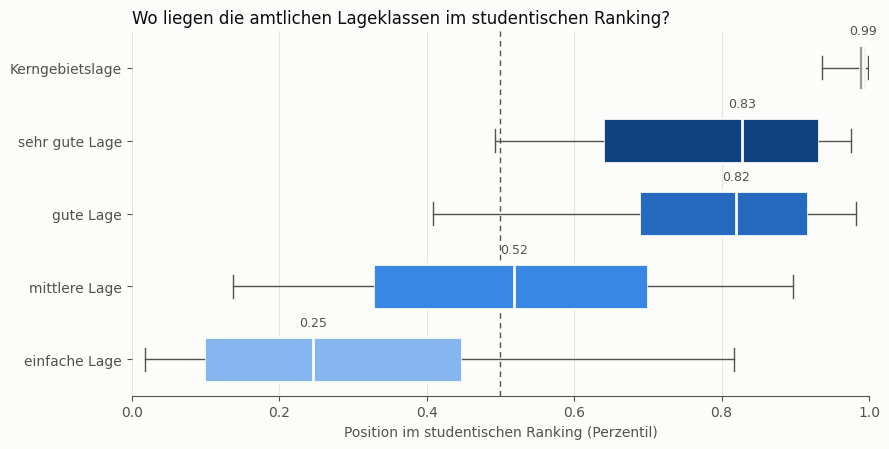

In [59]:
import numpy as np
import matplotlib.pyplot as plt

ORDER  = ["einfache Lage", "mittlere Lage", "gute Lage", "sehr gute Lage", "Kerngebietslage"]
FARBEN = {"einfache Lage": "#86b6ef", "mittlere Lage": "#3987e5", "gute Lage": "#256abf",
          "sehr gute Lage": "#104281", "Kerngebietslage": "#9a9992"}
SURFACE, INK, INK2 = "#fcfcfb", "#0b0b0b", "#52514e"

daten = [gdf.loc[gdf["lage_stufe"] == s, "pct_stud"].dropna().values for s in ORDER]

fig, ax = plt.subplots(figsize=(9, 4.6), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
bp = ax.boxplot(daten, vert=False, widths=0.62, whis=(5, 95), showfliers=False,
                patch_artist=True, medianprops=dict(color=SURFACE, linewidth=2),
                boxprops=dict(linewidth=0), whiskerprops=dict(color=INK2, linewidth=1),
                capprops=dict(color=INK2, linewidth=1))
for patch, s in zip(bp["boxes"], ORDER):
    patch.set_facecolor(FARBEN[s]); patch.set_edgecolor(SURFACE); patch.set_linewidth(2)

ax.axvline(0.5, color=INK2, linewidth=1, linestyle=(0, (4, 3)), zorder=0)
for i, s in enumerate(ORDER, start=1):
    med = gdf.loc[gdf["lage_stufe"] == s, "pct_stud"].median()
    ax.text(med, i + 0.42, f"{med:.2f}", ha="center", va="bottom", fontsize=9, color=INK2)

ax.set_yticklabels(ORDER, color=INK)
ax.set_xlim(0, 1)
ax.set_xlabel("Position im studentischen Ranking (Perzentil)", color=INK2)
ax.set_title("Wo liegen die amtlichen Lageklassen im studentischen Ranking?",
             color=INK, loc="left", fontsize=12)
for sp in ("top", "right", "left"): ax.spines[sp].set_visible(False)
ax.spines["bottom"].set_color(INK2); ax.tick_params(colors=INK2)
ax.grid(axis="x", color="#e6e5e1", linewidth=0.8); ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig(OUT / "perzentil_boxplot.png", dpi=200, facecolor=SURFACE, bbox_inches="tight")
plt.show()

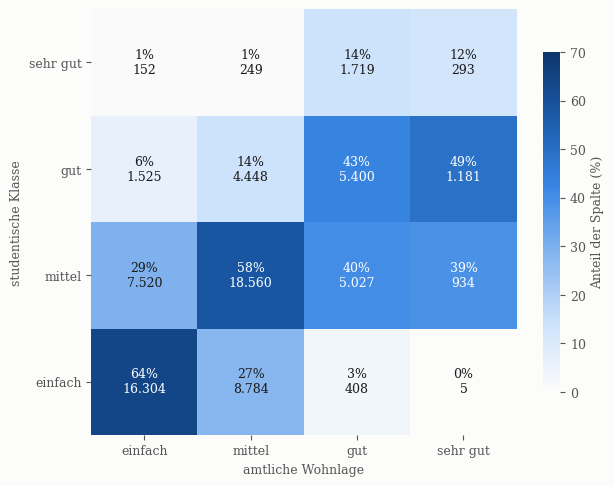

In [69]:
from matplotlib.colors import LinearSegmentedColormap

kt = pd.crosstab(gdf.loc[mask4, "stud_rang"], gdf.loc[mask4, "offiziell_rang"])
anteil = kt.div(kt.sum(axis=0), axis=1) * 100      # Spaltenanteile

BLAU = LinearSegmentedColormap.from_list(
    "blau", ["#fcfcfb", "#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"])
LABELS = ["einfach", "mittel", "gut", "sehr gut"]

fig, ax = plt.subplots(figsize=(6.4, 5.2), facecolor=SURFACE)
im = ax.imshow(anteil.values, cmap=BLAU, vmin=0, vmax=70, origin="lower")
for i in range(4):
    for j in range(4):
        v = anteil.values[i, j]
        ax.text(j, i, f"{v:.0f}%\n{kt.values[i, j]:,}".replace(",", "."),
                ha="center", va="center", fontsize=9,
                color="#ffffff" if v > 35 else INK)
ax.set_xticks(range(4), LABELS); ax.set_yticks(range(4), LABELS)
ax.set_xlabel("amtliche Wohnlage", color=INK2)
ax.set_ylabel("studentische Klasse", color=INK2)
ax.tick_params(colors=INK2); [ax.spines[s].set_visible(False) for s in ax.spines]
cb = fig.colorbar(im, ax=ax, shrink=0.75); cb.set_label("Anteil der Spalte (%)", color=INK2)
cb.ax.tick_params(colors=INK2); cb.outline.set_visible(False)
plt.tight_layout()
plt.savefig(OUT / "kreuztabelle_heatmap.png", dpi=200, facecolor=SURFACE, bbox_inches="tight")
plt.show()

# Export

In [62]:
#Export mit sprechenden Spaltennamen
EXPORT_NAMEN = {
  # Adresse
    "strasse":             "strasse",
    "hausnummer":          "hausnummer",
    "ortsteil":            "ortsteil",
    "geo_qualitaet":       "geo_qualitaet",
    "innenstadt_lage":    "amtl_innenstadt",                  # True/False, steckt in amtl_wohnlage
    "kerngebiet":         "amtl_kerngebiet",                  # True/False, steckt in amtl_wohnlage_stufe
  # amtlich (Mietspiegel 2025–2027)
    #"wohnlage_offiziell": "amtl_wohnlage",                   # 9 Originalkategorien, steckt in amtl_wohnlage_stufe
    "offiziell_rang":     "amtl_rang",                        # 1–4, Zahl zu amtl_wohnlage_stufe
    "lage_stufe":          "amtl_wohnlage_stufe",
    #"faktor":              "amtl_mietfaktor",
  # studentisch
    "score":               "stud_score_gesamt",
    #"pct_stud":           "stud_perzentil",                   # Rang von stud_score_gesamt
    "quartil":            "stud_quartil",                     # 1–4, Zahl zu stud_quartil_label
    "quartil_label":       "stud_quartil_label",
    "stud_rang":          "skewed_stud_rang_amtl_anteilen",           # Klassen mit gleichen Anteilen wie offizielle Klassen (Imbalance)
    "stud_label":         "skewed_stud_rang_amtl_anteile_label",     # Text-Label dazu (nur falls angelegt)
  # Vergleich
    #"diff":               "vergleich_diff",                   # stud. minus amtl. Rang, steckt in vergleich_kategorie
    "vergleich":           "vergleich_kategorie",
}

basis = [c for c in EXPORT_NAMEN if c in gdf.columns]
indikatoren = [c for c in gdf.columns if c.startswith(("dist_", "score_"))]

export = gdf[basis + indikatoren].rename(columns=EXPORT_NAMEN)

for c in ["amtl_rang", "skewed_stud_rang_amtl_anteilen", "vergleich_diff"]:
    if c in export:
        export[c] = export[c].astype("Int64")

wgs = gdf.geometry.to_crs(CRS_WGS)
export["lon"] = wgs.x.round(6)
export["lat"] = wgs.y.round(6)

export.to_csv(OUT / "wohnlage_studentisch_mit_vergleich.csv", index=False)
gpd.GeoDataFrame(export.drop(columns=["lon", "lat"]), geometry=wgs, crs=CRS_WGS).to_file(
    OUT / "wohnlage_studentisch_mit_vergleich.geojson", driver="GeoJSON")

print(len(export.columns), "Spalten:", list(export.columns))
print("fertig:", OUT / "wohnlage_studentisch_mit_vergleich.csv")

46 Spalten: ['strasse', 'hausnummer', 'ortsteil', 'geo_qualitaet', 'amtl_innenstadt', 'amtl_kerngebiet', 'amtl_rang', 'amtl_wohnlage_stufe', 'stud_score_gesamt', 'stud_quartil', 'stud_quartil_label', 'skewed_stud_rang_amtl_anteilen', 'skewed_stud_rang_amtl_anteile_label', 'vergleich_kategorie', 'dist_oepnv', 'dist_discounter', 'dist_fitnessstudio', 'dist_cafe', 'dist_bar_club', 'dist_spaeti', 'dist_sportplaetze', 'dist_doener', 'dist_freibad', 'dist_mensa', 'dist_bibliothek', 'dist_uni', 'dist_innenstadt', 'dist_park', 'dist_see', 'score_oepnv', 'score_innenstadt', 'score_fitnessstudio', 'score_uni', 'score_discounter', 'score_bar_club', 'score_spaeti', 'score_see', 'score_cafe', 'score_bibliothek', 'score_doener', 'score_sportplaetze', 'score_park', 'score_mensa', 'score_freibad', 'lon', 'lat']
fertig: output/wohnlage_studentisch_mit_vergleich.csv


# Wo wohnen Studenten tatsächlich?

In [63]:
import pandas as pd, numpy as np, geopandas as gpd

CSV_PFAD = "/content/drive/MyDrive/Computational Spatial Humanities/straßen.csv"
CUTOFF   = "2026-07-27"       # alles davor war Testphase

befr = pd.read_csv(CSV_PFAD)
befr["ts"] = pd.to_datetime(befr["timestamp"])
befr = befr[befr["ts"] >= CUTOFF].copy()
print(f"{len(befr)} Sessions ab {CUTOFF}")

def norm_str(s):
    s = str(s).strip().lower().replace("str.", "straße").replace("ß", "ss")
    return " ".join(s.split())

befr["key_str"] = befr["straße"].map(norm_str)
sessions = befr.groupby("key_str").size().rename("n_sessions")

tmp = gdf.loc[valid, ["strasse", "geometry"]].copy()
tmp["x"], tmp["y"] = tmp.geometry.x, tmp.geometry.y
tmp["key_str"] = tmp["strasse"].map(norm_str)
zentro = tmp.groupby("key_str").agg(x=("x", "mean"), y=("y", "mean"),
                                    name=("strasse", "first"))

treffer = zentro.join(sessions, how="inner")
fehlend = sorted(set(sessions.index) - set(zentro.index))
print(f"{len(treffer)} von {sessions.size} Straßen gematcht, "
      f"{int(treffer.n_sessions.sum())} von {int(sessions.sum())} Sessions abgedeckt")
if fehlend:
    print("nicht gefunden:", fehlend)

befr_gdf = gpd.GeoDataFrame(treffer.reset_index(),
    geometry=gpd.points_from_xy(treffer.x, treffer.y), crs=CRS_METRIC)

149 Sessions ab 2026-07-27
115 von 116 Straßen gematcht, 148 von 149 Sessions abgedeckt
nicht gefunden: ['robert-koch-platz']


In [64]:
import folium
z = befr_gdf.to_crs(CRS_WGS)
m = folium.Map(location=[51.34, 12.37], zoom_start=12, tiles="cartodbpositron")
folium.GeoJson(ortsteile.to_crs(CRS_WGS),
    style_function=lambda f: {"color": "#999", "weight": 1, "fillOpacity": 0}).add_to(m)
for _, r in z.iterrows():
    folium.CircleMarker([r.geometry.y, r.geometry.x],
        radius=4 + 2.5*np.sqrt(r.n_sessions), color="#1f4e79",
        fill=True, fill_opacity=0.6, weight=1,
        popup=f"{r['name']}: {int(r.n_sessions)} Sessions").add_to(m)
m

/usr/local/lib/python3.13/dist-packages/folium/raster_layers.py:130: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tiles = tiles.build_url(fill_subdomain=False, scale_factor="{r}")  # type: ignore


In [65]:

befr_wgs = befr_gdf.to_crs(CRS_WGS)

befr_out = pd.DataFrame(befr_gdf.drop(columns=["geometry", "x", "y", "key_str"],
                                      errors="ignore"))
befr_out["lon"] = befr_wgs.geometry.x.round(6)
befr_out["lat"] = befr_wgs.geometry.y.round(6)
befr_out = befr_out.sort_values("n_sessions", ascending=False)

befr_out.to_csv(OUT / "befragte_strassen.csv", index=False)
befr_wgs.to_file(OUT / "befragte_strassen.geojson", driver="GeoJSON")

print(f"{len(befr_out)} Straßen, {int(befr_out.n_sessions.sum())} Sessions")
print("Spalten:", list(befr_out.columns))
print("fertig:", OUT / "befragte_strassen.csv")

115 Straßen, 148 Sessions
Spalten: ['name', 'n_sessions', 'lon', 'lat']
fertig: output/befragte_strassen.csv
